In [1]:
import torch
import pandas as pd
import numpy as np
import open_clip

print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("Pandas version:", pd.__version__)
print("NumPy version:", np.__version__)
print("open_clip imported successfully")

Torch version: 2.11.0+cu130
CUDA available: True
Pandas version: 3.0.1
NumPy version: 2.4.3
open_clip imported successfully


In [2]:
from soc.config import PROJECT_ROOT, CATALOG_CSV

print("Project root:", PROJECT_ROOT)
print("Catalog CSV:", CATALOG_CSV)

Project root: /home/aaa79306/Farzad/Projects/SOC
Catalog CSV: /home/aaa79306/Farzad/Projects/SOC/data/metadata/catalog.csv


In [3]:
from soc.data.catalog import load_catalog

df = load_catalog(CATALOG_CSV)
df.head()

,item_id,image_path,category,color,style
0,1,data/catalog_images/shoe_01.jpg,shoes,white,casual
1,2,data/catalog_images/shoe_02.jpg,shoes,black,formal
2,3,data/catalog_images/bag_01.jpg,bag,brown,casual
3,4,data/catalog_images/jacket_01.jpg,jacket,blue,smart-casual
4,5,data/catalog_images/trouser_01.jpg,trouser,black,formal


In [1]:
from soc.inference.recommend import recommend_from_image
from soc.explain.formatter import build_explanation_payload

query_image = "data/query_images/test_outfit.jpg"

results = recommend_from_image(
    query_image_path=query_image,
    top_k=5,
    target_category="shoes",
)

payload = build_explanation_payload(
    query_image_path=query_image,
    target_category="shoes",
    recommendations_df=results,
)

payload

{'query': {'image_path': 'data/query_images/test_outfit.jpg',
  'target_category': 'shoes'},
 'recommendations': [{'rank': 1,
   'item_id': 2,
   'category': 'shoes',
   'score': 0.27829933166503906,
   'color': 'black',
   'style': 'formal',
   'image_path': 'data/catalog_images/shoe_02.jpg'},
  {'rank': 2,
   'item_id': 1,
   'category': 'shoes',
   'score': 0.1645069569349289,
   'color': 'white',
   'style': 'casual',
   'image_path': 'data/catalog_images/shoe_01.jpg'}]}

In [1]:
from soc.inference.recommend import recommend_from_image
from soc.explain.formatter import build_explanation_payload
from soc.explain.prompt_builder import build_explanation_prompt

query_image = "data/query_images/test_outfit.jpg"

results = recommend_from_image(
    query_image_path=query_image,
    top_k=5,
    target_category="shoes",
)

payload = build_explanation_payload(
    query_image_path=query_image,
    target_category="shoes",
    recommendations_df=results,
)

prompt = build_explanation_prompt(payload)
print(prompt)

You are helping explain fashion recommendations to a user.
Use only the information provided below.
Do not invent fabrics, occasions, seasons, brands, or fine-grained visual details unless they are explicitly given.
Keep the explanation short, clear, and user-friendly.

Task:
Explain why these recommended items may suit the user's outfit.
Mention general alignment in category, color, style, and overall visual coherence when supported by the data.
Do not mention technical terms like embeddings, cosine similarity, or CLIP.

Input summary:
- Query image path: data/query_images/test_outfit.jpg
- Target category: shoes

Recommended items:
- rank=1, item_id=2, category=shoes, score=0.27829933166503906, color=black, style=formal
- rank=2, item_id=1, category=shoes, score=0.1645069569349289, color=white, style=casual

Output requirements:
- Write one short paragraph, around 3 to 5 sentences.
- Sound natural and helpful.
- Focus on why the suggestions are reasonable as complementary items.
- If

In [2]:
from soc.inference.recommend import recommend_from_image
from soc.explain.generate import generate_explanation
from soc.explain.llm_mock import MockLLM

query_image = "data/query_images/test_outfit.jpg"

results = recommend_from_image(
    query_image_path=query_image,
    top_k=5,
    target_category="shoes",
)

llm = MockLLM()

output = generate_explanation(
    query_image_path=query_image,
    target_category="shoes",
    recommendations_df=results,
    llm=llm,
)

print("EXPLANATION:\n")
print(output["explanation"])

EXPLANATION:

These recommendations were selected because they appear to align with the requested category and show a generally consistent visual style with the outfit. The suggested items seem to support a balanced and coordinated look based on the available recommendation signals. This explanation is currently generated by a mock LLM backend.


In [1]:
from soc.explain.llm_ollama import OllamaLLM

llm = OllamaLLM(model_name="llama3.2:3b")
print(llm.generate("Write one short sentence about black casual shoes."))

Black casual shoes are a versatile and timeless choice that can easily complement a variety of outfits.


In [ ]:
from soc.inference.recommend import recommend_from_image
from soc.explain.generate import generate_explanation
from soc.explain.llm_factory import get_llm

query_image = "data/query_images/test_outfit.jpg"

results = recommend_from_image(
    query_image_path=query_image,
    top_k=5,
    target_category="shoes",
)

llm = get_llm()

output = generate_explanation(
    query_image_path=query_image,
    target_category="shoes",
    recommendations_df=results,
    llm=llm,
)

print(output["explanation"])

EXPLANATION:

Based on your outfit, we think the recommended shoes would complement it well. The first suggestion, black formal shoes, aligns with the overall style and color palette of your image. It's likely that these shoes would add a polished touch to your ensemble. The second option, white casual shoes, might be a bit more unexpected but could still work if you're going for a bold or contrasting look.


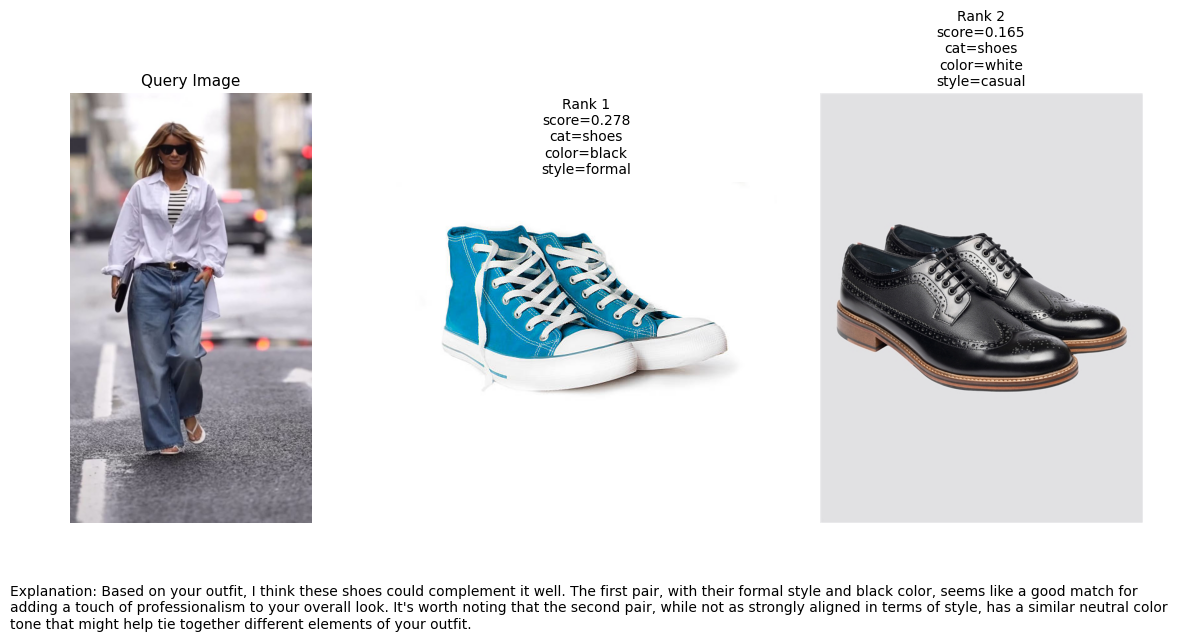

In [1]:
from soc.inference.recommend import recommend_from_image
from soc.explain.generate import generate_explanation
from soc.explain.llm_factory import get_llm
from soc.utils.inspect_results import show_query_and_recommendations

from soc.config import QUERY_IMG_DIR

query_image = QUERY_IMG_DIR / "test_outfit.jpg"

results = recommend_from_image(
    query_image_path=query_image,
    top_k=5,
    target_category="shoes",
)

llm = get_llm()

output = generate_explanation(
    query_image_path=query_image,
    target_category="shoes",
    recommendations_df=results,
    llm=llm,
)

show_query_and_recommendations(
    query_image_path=query_image,
    recommendations_df=results,
    explanation=output["explanation"],
    top_k=5,
)